In [1]:
import numpy as np
import pandas as pd
import os
import time
import corner
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from astropy.visualization import make_lupton_rgb
from astropy.visualization import astropy_mpl_style
plt.style.use(astropy_mpl_style)

import lenstronomy
from lenstronomy.Util import util
from lenstronomy.Workflow.fitting_sequence import FittingSequence
from lenstronomy.Plots import chain_plot
from lenstronomy.Plots.model_plot import ModelPlot

In [2]:
# For OSG
script = False

if(script):
    name = sys.argv[1]
else:
    name = '4'
    

In [3]:
# Util Functions

# e1, e2 from q and phi
def q_phi_to_ellipticity(q, phi):
    """
    Convert axis ratio q and position angle phi to ellipticity components e1, e2.
    
    Parameters:
        q:   axis ratio (b/a), between 0 and 1
        phi: position angle in radians
    """
    e = (1 - q) / (1 + q)
    e1 = e * np.cos(2 * phi)
    e2 = e * np.sin(2 * phi)
    return e1, e2

# Plot all RGB images of strong lenses
def make_plot_all(objects, data, Q=9, stretch=40, minimum=(0, 0, 0)):
    for i in range(len(objects)):
        if(i%10 == 0):
            plt.figure(figsize=(12,2))
            for j in range(10):
                if(i+j > len(objects)-1): break
                plt.subplot(1,10,j+1)
                rgb = make_lupton_rgb(objects[i+j][0], objects[i+j][1], objects[i+j][2], 
                                    Q=Q, stretch=stretch, minimum=minimum)
                plt.imshow(rgb, aspect='equal')
                plt.xticks([], [])
                plt.yticks([], []) 
            plt.show() 
            
#Plot observed, reconstructed, and residual
def model_plot_all_bands(modelPlot, name):
    f, axes = plt.subplots(1, 3, figsize=(13, 12))

    modelPlot.data_plot(ax=axes[0], band_index=0, text="", colorbar_label="", no_arrow=True)
    modelPlot.model_plot(ax=axes[1], image_names=True, band_index=0, text="", colorbar_label="", no_arrow=True)
    modelPlot.normalized_residual_plot(ax=axes[2], v_min=-6, v_max=6, band_index=0,
                                           text="", colorbar_label="", no_arrow=True, cmap='PuOr') 

    axes[0].get_yaxis().set_visible(True)
    axes[0].grid(False)
    axes[0].set_yticks([])

    axes[0].set_title('Observed', fontsize=20)
    axes[1].set_title('Reconstructed', fontsize=20)
    axes[2].set_title('Normalized Residuals', fontsize=20)

    plt.tight_layout()
    
    # save figure if in script mode
    if script:
        plt.savefig(f"{name}_model.pdf", dpi=300, bbox_inches="tight")
    else:
        plt.savefig(f"Modeling_results/{name}_model.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    plt.close()
    
def plot_individual_trace_plots(name):
    # Results of MCMC chain
    sampler_type, samples_mcmc, param_mcmc, dist_mcmc = chain_list[1]

    # Individual trace plots:
    # @author: Anowar Shajib
    n_params = samples_mcmc.shape[1]
    #n_walkers = walkerRatio * n_params  
    n_walkers = fitting_kwargs_list[1][1]['n_walkers'] 
    n_step = int(samples_mcmc.shape[0] / n_walkers)

    print(f'number of steps: {n_step}')
    print(f'number of walkers: {n_walkers}')
    print(f'number of parameters: {n_params}')

    chain = np.empty((n_walkers, n_step, n_params))

    for i in np.arange(n_params):
        samples = samples_mcmc[:, i].T
        chain[:,:,i] = samples.reshape((n_step, n_walkers)).T

    mean_pos = np.zeros((n_params, n_step))
    median_pos = np.zeros((n_params, n_step))
    std_pos = np.zeros((n_params, n_step))
    q16_pos = np.zeros((n_params, n_step))
    q84_pos = np.zeros((n_params, n_step))
    
    for i in np.arange(n_params):
        for j in np.arange(n_step):
            mean_pos[i][j] = np.mean(chain[:, j, i])
            median_pos[i][j] = np.median(chain[:, j, i])
            std_pos[i][j] = np.std(chain[:, j, i])
            q16_pos[i][j] = np.percentile(chain[:, j, i], 16.)
            q84_pos[i][j] = np.percentile(chain[:, j, i], 84.)
    
    fig, ax = plt.subplots(n_params, sharex=True, figsize=(8, 6))

    burnin = -1
    last = n_step

    medians = []

    param_values = [median_pos[0][last-1], (q84_pos[0][last-1]-q16_pos[0][last-1])/2,
                    median_pos[1][last-1], (q84_pos[1][last-1]-q16_pos[1][last-1])/2]

    for i in range(n_params):
        print(param_mcmc[i], '{:.4f} ± {:.4f}'.format(median_pos[i][last-1],
                                                      (q84_pos[i][last-1]-q16_pos[i][last-1])/2))
       
        ax[i].plot(median_pos[i][:last], c='g')
        ax[i].axhline(np.median(median_pos[i][burnin:last]), c='r', lw=1)
        ax[i].fill_between(np.arange(last), q84_pos[i][:last], q16_pos[i][:last], alpha=0.4)
        ax[i].set_ylabel(param_mcmc[i], fontsize=10)
        ax[i].set_xlim(0, last)

        medians.append(np.median(median_pos[i][burnin:last]))

    # only save figure if in script mode
    fig.set_size_inches((12., 2*len(param_mcmc)))
    if script:
        plt.savefig(f"{name}_tracePlot.pdf", dpi=300, bbox_inches="tight")
    else:
        plt.savefig(f"Modeling_results/{name}_tracePlot.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    plt.close()

## Loading data (Euclid Simulations)

In [4]:
path = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/Euclid_Simulations/train/'
path_img = '/Users/jimenagonzalez/research/DSPL/Hybrid_SL_Modeling/data/candidates_tocompare/Euclid_Simulations/train/measurements_sersic-sie_sigma_noise=1.0e-02/'
path_mass = 'lens_mass_sersic-sie_sigma_noise=1.0e-02/'
path_lens_light = 'lens_light_sersic-sie_sigma_noise=1.0e-02/'
path_source_light = 'source_light_sersic-sie_sigma_noise=1.0e-02/'

if(script):
    path = ''
    path_img = ''
    path_mass = ''
    path_lens_light = ''
    path_source_light = ''
    
#Image
filepath = path_img + 'measurements_' + str(name) + '.npy'
arr = np.load(filepath)
image_data = np.array((arr, arr, arr))

#Saving all data into one dataframe
column_names1 = ['center_x_lens', 'center_y_lens', 'q_lens_mass', 'phi_lens_mass', 'EINSTEIN_RADIUS']
column_names2 = ['x_lens_light', 'y_lens_light', 'q_lens_light', 'phi_lens_light', 'n_sersic_lens_light', 
                 'R_sersic_lens_light', 'Io_lens']
column_names3 = ['center_x_source', 'center_y_source', 'q_source', 'phi_source', 'n_sersic_source_light', 
                 'R_sersic_source_light', 'Ie_source']

filename1 = path + path_mass + 'lens_mass_' + name + '.npy'
arr = np.load(filename1)
data_mass = pd.DataFrame([arr], columns=column_names1)

filename2 = path + path_lens_light  + 'lens_light_' + name + '.npy'
arr = np.load(filename2)
data_lens_light = pd.DataFrame([arr], columns = column_names2)

filename3 = path + path_source_light   + 'source_light_' + name + '.npy'
arr = np.load(filename3)
data_source_light = pd.DataFrame([arr], columns = column_names3)

# Adding ellipticity values
e1, e2 = q_phi_to_ellipticity(data_mass['q_lens_mass'], data_mass['phi_lens_mass'])
data_mass['e1_lens'] = e1
data_mass['e2_lens'] = e2

e1, e2 = q_phi_to_ellipticity(data_lens_light['q_lens_light'], data_lens_light['phi_lens_light'])
data_mass['e1_lens_light'] = e1
data_mass['e2_lens_light'] = e2

e1, e2 = q_phi_to_ellipticity(data_source_light['q_source'], data_source_light['phi_source'])
data_source_light['e1_source_light'] = e1
data_source_light['e2_source_light'] = e2

data_combined = pd.concat([data_mass, data_lens_light, data_source_light], axis=1)
data = data_combined #Complete data
data.head()

,center_x_lens,center_y_lens,q_lens_mass,phi_lens_mass,EINSTEIN_RADIUS,e1_lens,e2_lens,e1_lens_light,e2_lens_light,x_lens_light,...,Io_lens,center_x_source,center_y_source,q_source,phi_source,n_sersic_source_light,R_sersic_source_light,Ie_source,e1_source_light,e2_source_light
0,-0.016201,0.017466,0.746559,1.045691,0.999022,-0.072176,0.125886,0.004037,0.011039,-0.05392,...,0.0,0.0,0.0,0.350357,0.584263,1.437104,0.964941,13.623817,0.188351,0.442687


(3, 128, 128)


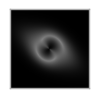

In [5]:
print(image_data.shape)

make_plot_all([image_data], data)

## Lenstronomy Modeling

In [6]:
# Euclid data specifics - For now no noise
background_rms = .005  #  rms of background noise per pixel
exp_time = 1.  #  exposure time (arbitrary units, flux per pixel is in units #photons/exp_time unit)
numPix = 128  #  cutout pixel size per axis
pixel_scale = 0.1  #  pixel size in arcsec (area per pixel = pixel_scale**2)
fwhm = 0.05  # full width at half maximum of PSF
psf_type = 'GAUSSIAN'  # 'GAUSSIAN', 'PIXEL', 'NONE'

# generate the coordinate grid and image properties (we only read out the relevant lines we need)
_, _, ra_at_xy_0, dec_at_xy_0, _, _, Mpix2coord, _ = util.make_grid_with_coordtransform(numPix=numPix, 
                        deltapix=pixel_scale, center_ra=0, center_dec=0, subgrid_res=1, inverse=False)

kwargs_data = {'background_rms': background_rms, 'exposure_time': exp_time, 'ra_at_xy_0': ra_at_xy_0,  
            'dec_at_xy_0': dec_at_xy_0, 'transform_pix2angle': Mpix2coord, 'image_data': image_data[0]}
kwargs_psf = {'psf_type': 'GAUSSIAN', 'fwhm': fwhm, 'pixel_size': pixel_scale, 'truncation': 3}
kwargs_numerics = {'supersampling_factor': 1, 'supersampling_convolution': False}

In [7]:
# Defining parameter space to explore & initial points

# Lens
fixed_lens = []
kwargs_lens_init = []
kwargs_lens_sigma = []
kwargs_lower_lens = []
kwargs_upper_lens = []

fixed_lens.append({}) 
kwargs_lens_init.append({'theta_E': 0.6, 'e1': 0., 'e2': 0., 'center_x': 0., 'center_y': 0.})
kwargs_lens_sigma.append({'theta_E': .2, 'e1': 0.05, 'e2': 0.05, 'center_x': 0.05, 'center_y': 0.05})
kwargs_lower_lens.append({'theta_E': 0.1, 'e1': -0.5, 'e2': -0.5, 'center_x': -2, 'center_y': -2})
kwargs_upper_lens.append({'theta_E': 3., 'e1': 0.5, 'e2': 0.5, 'center_x': 2, 'center_y': 2})

fixed_lens.append({}) # {'ra_0': 0, 'dec_0': 0}
lens_params = [kwargs_lens_init, kwargs_lens_sigma, fixed_lens, kwargs_lower_lens, kwargs_upper_lens]

# Source
fixed_source = []
kwargs_source_init = []
kwargs_source_sigma = []
kwargs_lower_source = []
kwargs_upper_source = []

fixed_source.append({})
kwargs_source_init.append({'R_sersic': 0.2, 'n_sersic': 1, 'e1': 0, 'e2': 0, 'center_x': 0., 'center_y': 0, 'amp': 16})
kwargs_source_sigma.append({'n_sersic': 0.5, 'R_sersic': 0.1, 'e1': 0.05, 'e2': 0.05, 'center_x': 0.2, 'center_y': 0.2, 'amp': 10})
kwargs_lower_source.append({'e1': -0.5, 'e2': -0.5, 'R_sersic': 0.001, 'n_sersic': .5, 'center_x': -2, 'center_y': -2, 'amp': 0})
kwargs_upper_source.append({'e1': 0.5, 'e2': 0.5, 'R_sersic': 10, 'n_sersic': 5., 'center_x': 2, 'center_y': 2, 'amp': 100})

source_params = [kwargs_source_init, kwargs_source_sigma, fixed_source, kwargs_lower_source, kwargs_upper_source]

# Complete parameter space
kwargs_params = {'lens_model': lens_params, 'source_model': source_params,} 

## Lenstronomy Fitting

In [8]:
# Setting true parameter values
row = data.iloc[0]
kwargs_lens = [{'theta_E': row['EINSTEIN_RADIUS'], 'center_x': row['center_x_lens'], 
                'center_y': row['center_y_lens'], 
                'e1': row['e1_lens'], 'e2': row['e2_lens']}]
kwargs_source = [{'amp': 16, 'R_sersic': row ['R_sersic_source_light'], 'n_sersic': row['n_sersic_source_light'], 
                  'e1': row['e1_source_light'], 'e2': row['e2_source_light'], 'center_x': row['center_x_source'], 
                  'center_y': row['center_y_source']}]

In [9]:
# Models to fit
lens_model_list = ['SIE']
source_model_list = ['SERSIC_ELLIPSE']

multi_band_list = [[kwargs_data, kwargs_psf, kwargs_numerics]]
kwargs_likelihood = {'source_marg': False}
kwargs_model = {'lens_model_list': lens_model_list, 'source_light_model_list': source_model_list}
kwargs_data_joint = {'multi_band_list': multi_band_list, 'multi_band_type': 'single-band'}
kwargs_constraints = {'linear_solver': True}  # optional, if 'linear_solver': False, lenstronomy does not apply 
#a linear inversion of the 'amp' parameters during fitting but instead samples them.

# Fitting
fitting_seq = FittingSequence(kwargs_data_joint, kwargs_model, kwargs_constraints, kwargs_likelihood, 
                              kwargs_params, verbose=True)



fitting_kwargs_list = [['PSO', {'sigma_scale': 1., 'n_particles': 200, 'n_iterations': 100}],
                       ['MCMC', {'n_burn': 100, 'n_run': 600, 'n_walkers': 200, 'sigma_scale': .1}]]
# MCMC: n_run = 600, n_walkers: 200, n_burn = 100
chain_list = fitting_seq.fit_sequence(fitting_kwargs_list)
kwargs_result = fitting_seq.best_fit() 

Computing the PSO ...
10
20
30
40
50
60
70
80
90
100
Max iteration reached! Stopping.
-0.0033283590693865533 reduced X^2 of best position
-27.245947341998324 log likelihood
16372.0 effective number of data points
[{'theta_E': 1.9977775638153432, 'e1': -0.07174583076596164, 'e2': 0.12627569204376374, 'center_x': -0.032516496763624614, 'center_y': 0.03478821582970905}] lens result
[{'amp': 1, 'R_sersic': 1.1427451453358695, 'n_sersic': 1.4427724263860235, 'e1': 0.18896715828780758, 'e2': 0.44242171542173797, 'center_x': -0.00011559373430749837, 'center_y': -0.00025155978767847626}] source result
[] lens light result
[] point source result
[] tracer source result
{} special param result
59.74404501914978 time used for  PSO
MCMC selected. Sampling with default option emcee.


100%|█████████████████████████████████████████████████████████████████████████████████████████| 700/700 [10:33<00:00,  1.11it/s]

Computing the MCMC...
Number of walkers =  200
Burn-in iterations:  100
Sampling iterations (in current run): 700
633.909832239151 time taken for MCMC sampling


-0.0033553312663229876 reduced X^2 of all evaluated imaging data combined (without degrees of freedom subtracted).
reduced chi^2 of data  0 =  0.003355331266322988


/Users/jimenagonzalez/Software/miniconda3/lib/python3.7/site-packages/lenstronomy/Plots/plot_util.py:352: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("gist_heat").copy()
  cmap_new.set_bad(color="k", alpha=1.0)
/Users/jimenagonzalez/Software/miniconda3/lib/python3.7/site-packages/lenstronomy/Plots/plot_util.py:353: MatplotlibDeprecationWarning: You are modifying the state of a globally registered colormap. This has been deprecated since 3.3 and in 3.6, you will not be able to modify a registered colormap in-place. To remove this warning, you can make a copy of the colormap first. cmap = mpl.cm.get_cmap("gist_heat").copy()
  cmap_new.set_under("k")
/Users/jimenagonzalez/Software/miniconda3/lib/python3.7/site-packages/lenstronomy/Plots/model_b

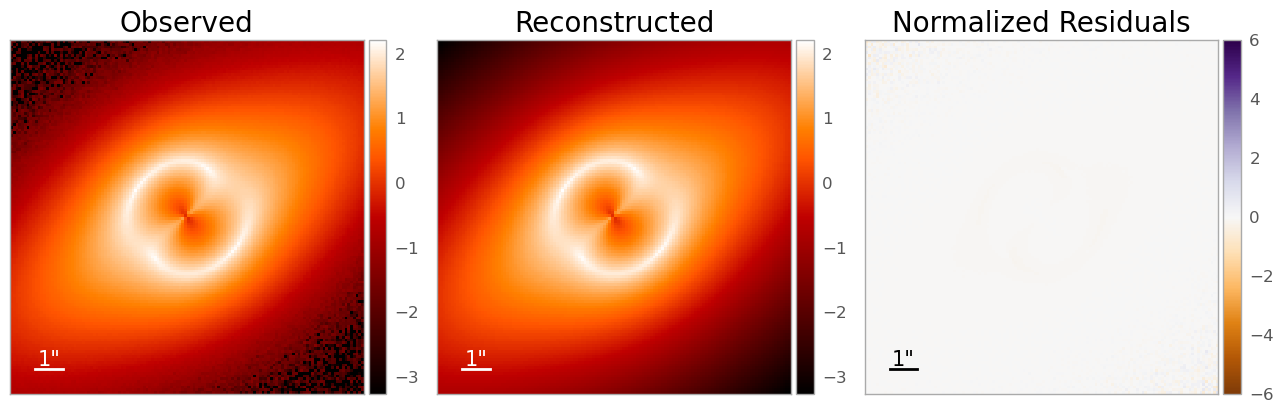

number of steps: 600
number of walkers: 200
number of parameters: 11
theta_E_lens0 1.9982 ± 0.0020
e1_lens0 -0.0721 ± 0.0014
e2_lens0 0.1257 ± 0.0023
center_x_lens0 -0.0324 ± 0.0019
center_y_lens0 0.0351 ± 0.0023
R_sersic_source_light0 1.1426 ± 0.0049
n_sersic_source_light0 1.4426 ± 0.0070
e1_source_light0 0.1886 ± 0.0024
e2_source_light0 0.4426 ± 0.0019
center_x_source_light0 -0.0003 ± 0.0026
center_y_source_light0 -0.0000 ± 0.0021


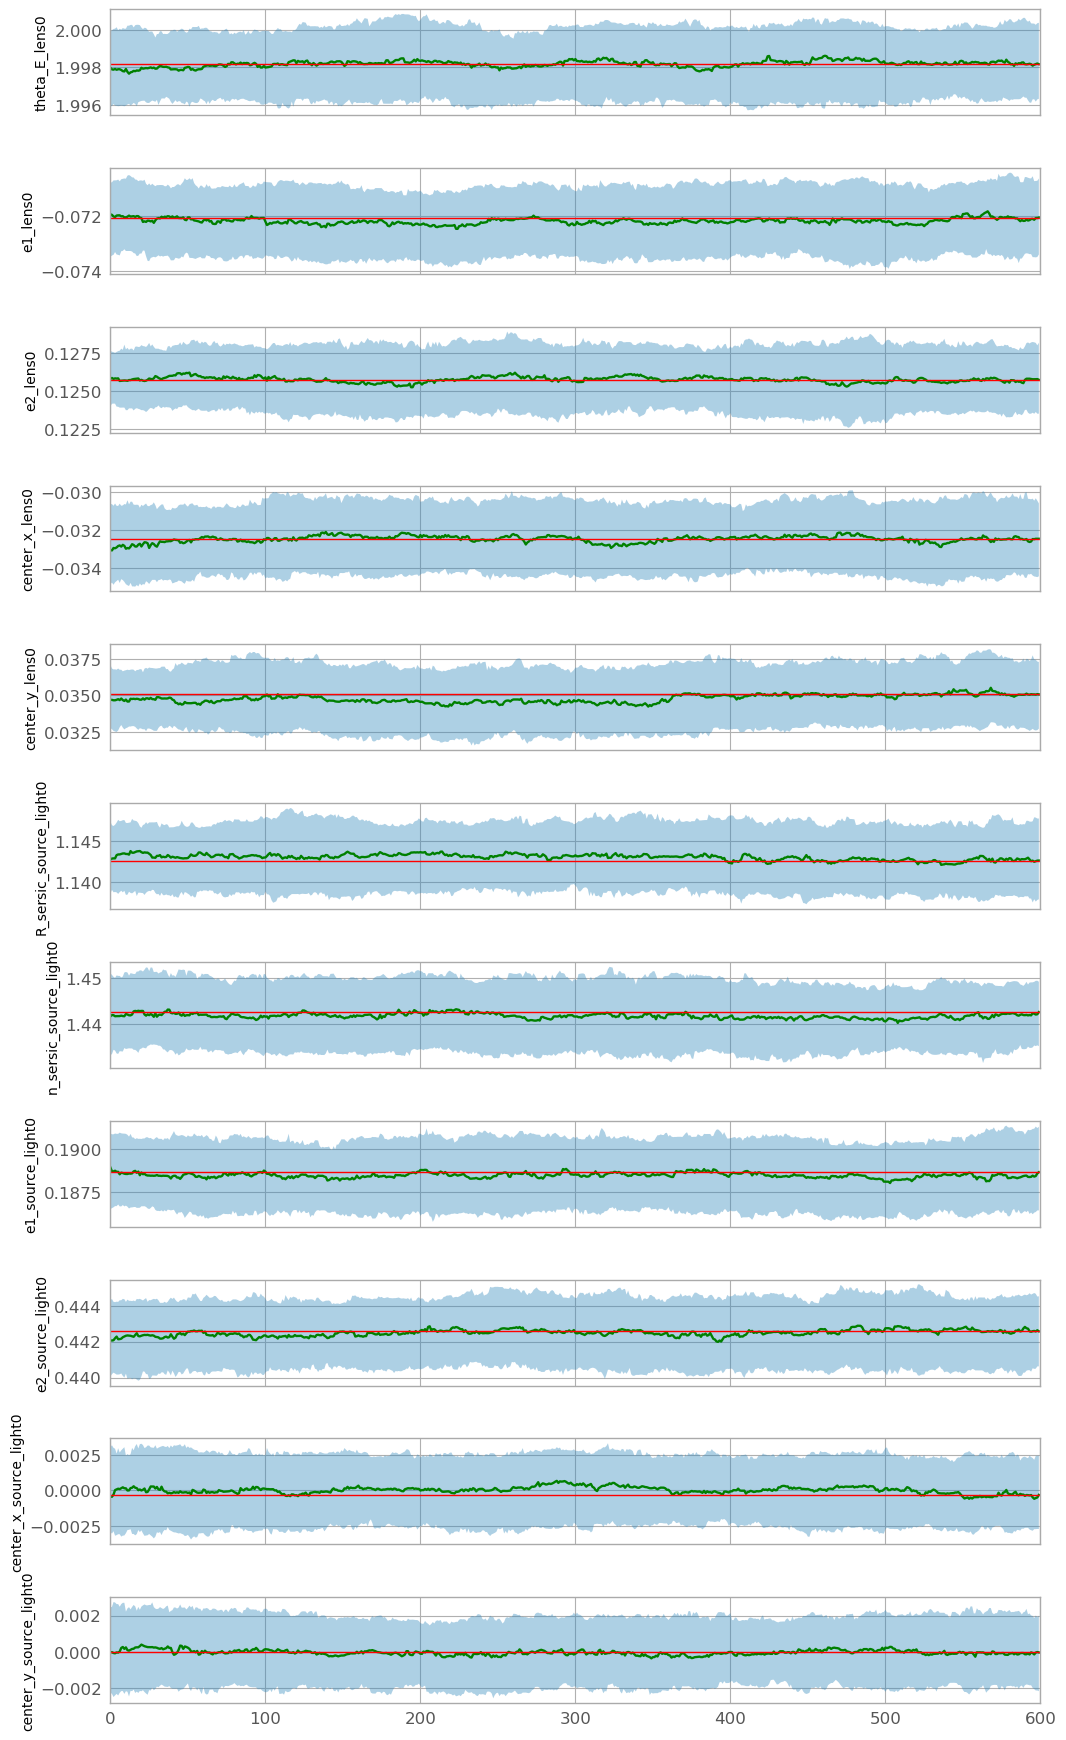

In [10]:
#Ploting reconstruction
modelPlot = ModelPlot(multi_band_list, kwargs_model, kwargs_result, arrow_size=0.02, cmap_string="gist_heat",
                     linear_solver=kwargs_constraints.get('linear_solver', True))
model_plot_all_bands(modelPlot, name)    

#Plotting MCMC individual trace plots
plot_individual_trace_plots(name)

number of non-linear parameters in the MCMC process:  11
parameters in order:  ['theta_E_lens0', 'e1_lens0', 'e2_lens0', 'center_x_lens0', 'center_y_lens0', 'R_sersic_source_light0', 'n_sersic_source_light0', 'e1_source_light0', 'e2_source_light0', 'center_x_source_light0', 'center_y_source_light0']
number of evaluations in the MCMC process:  120000
120000


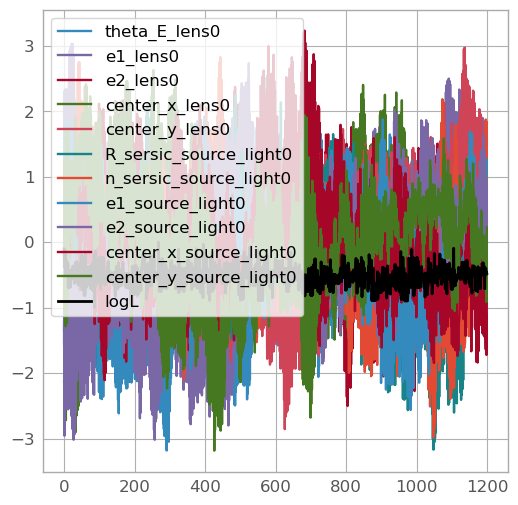

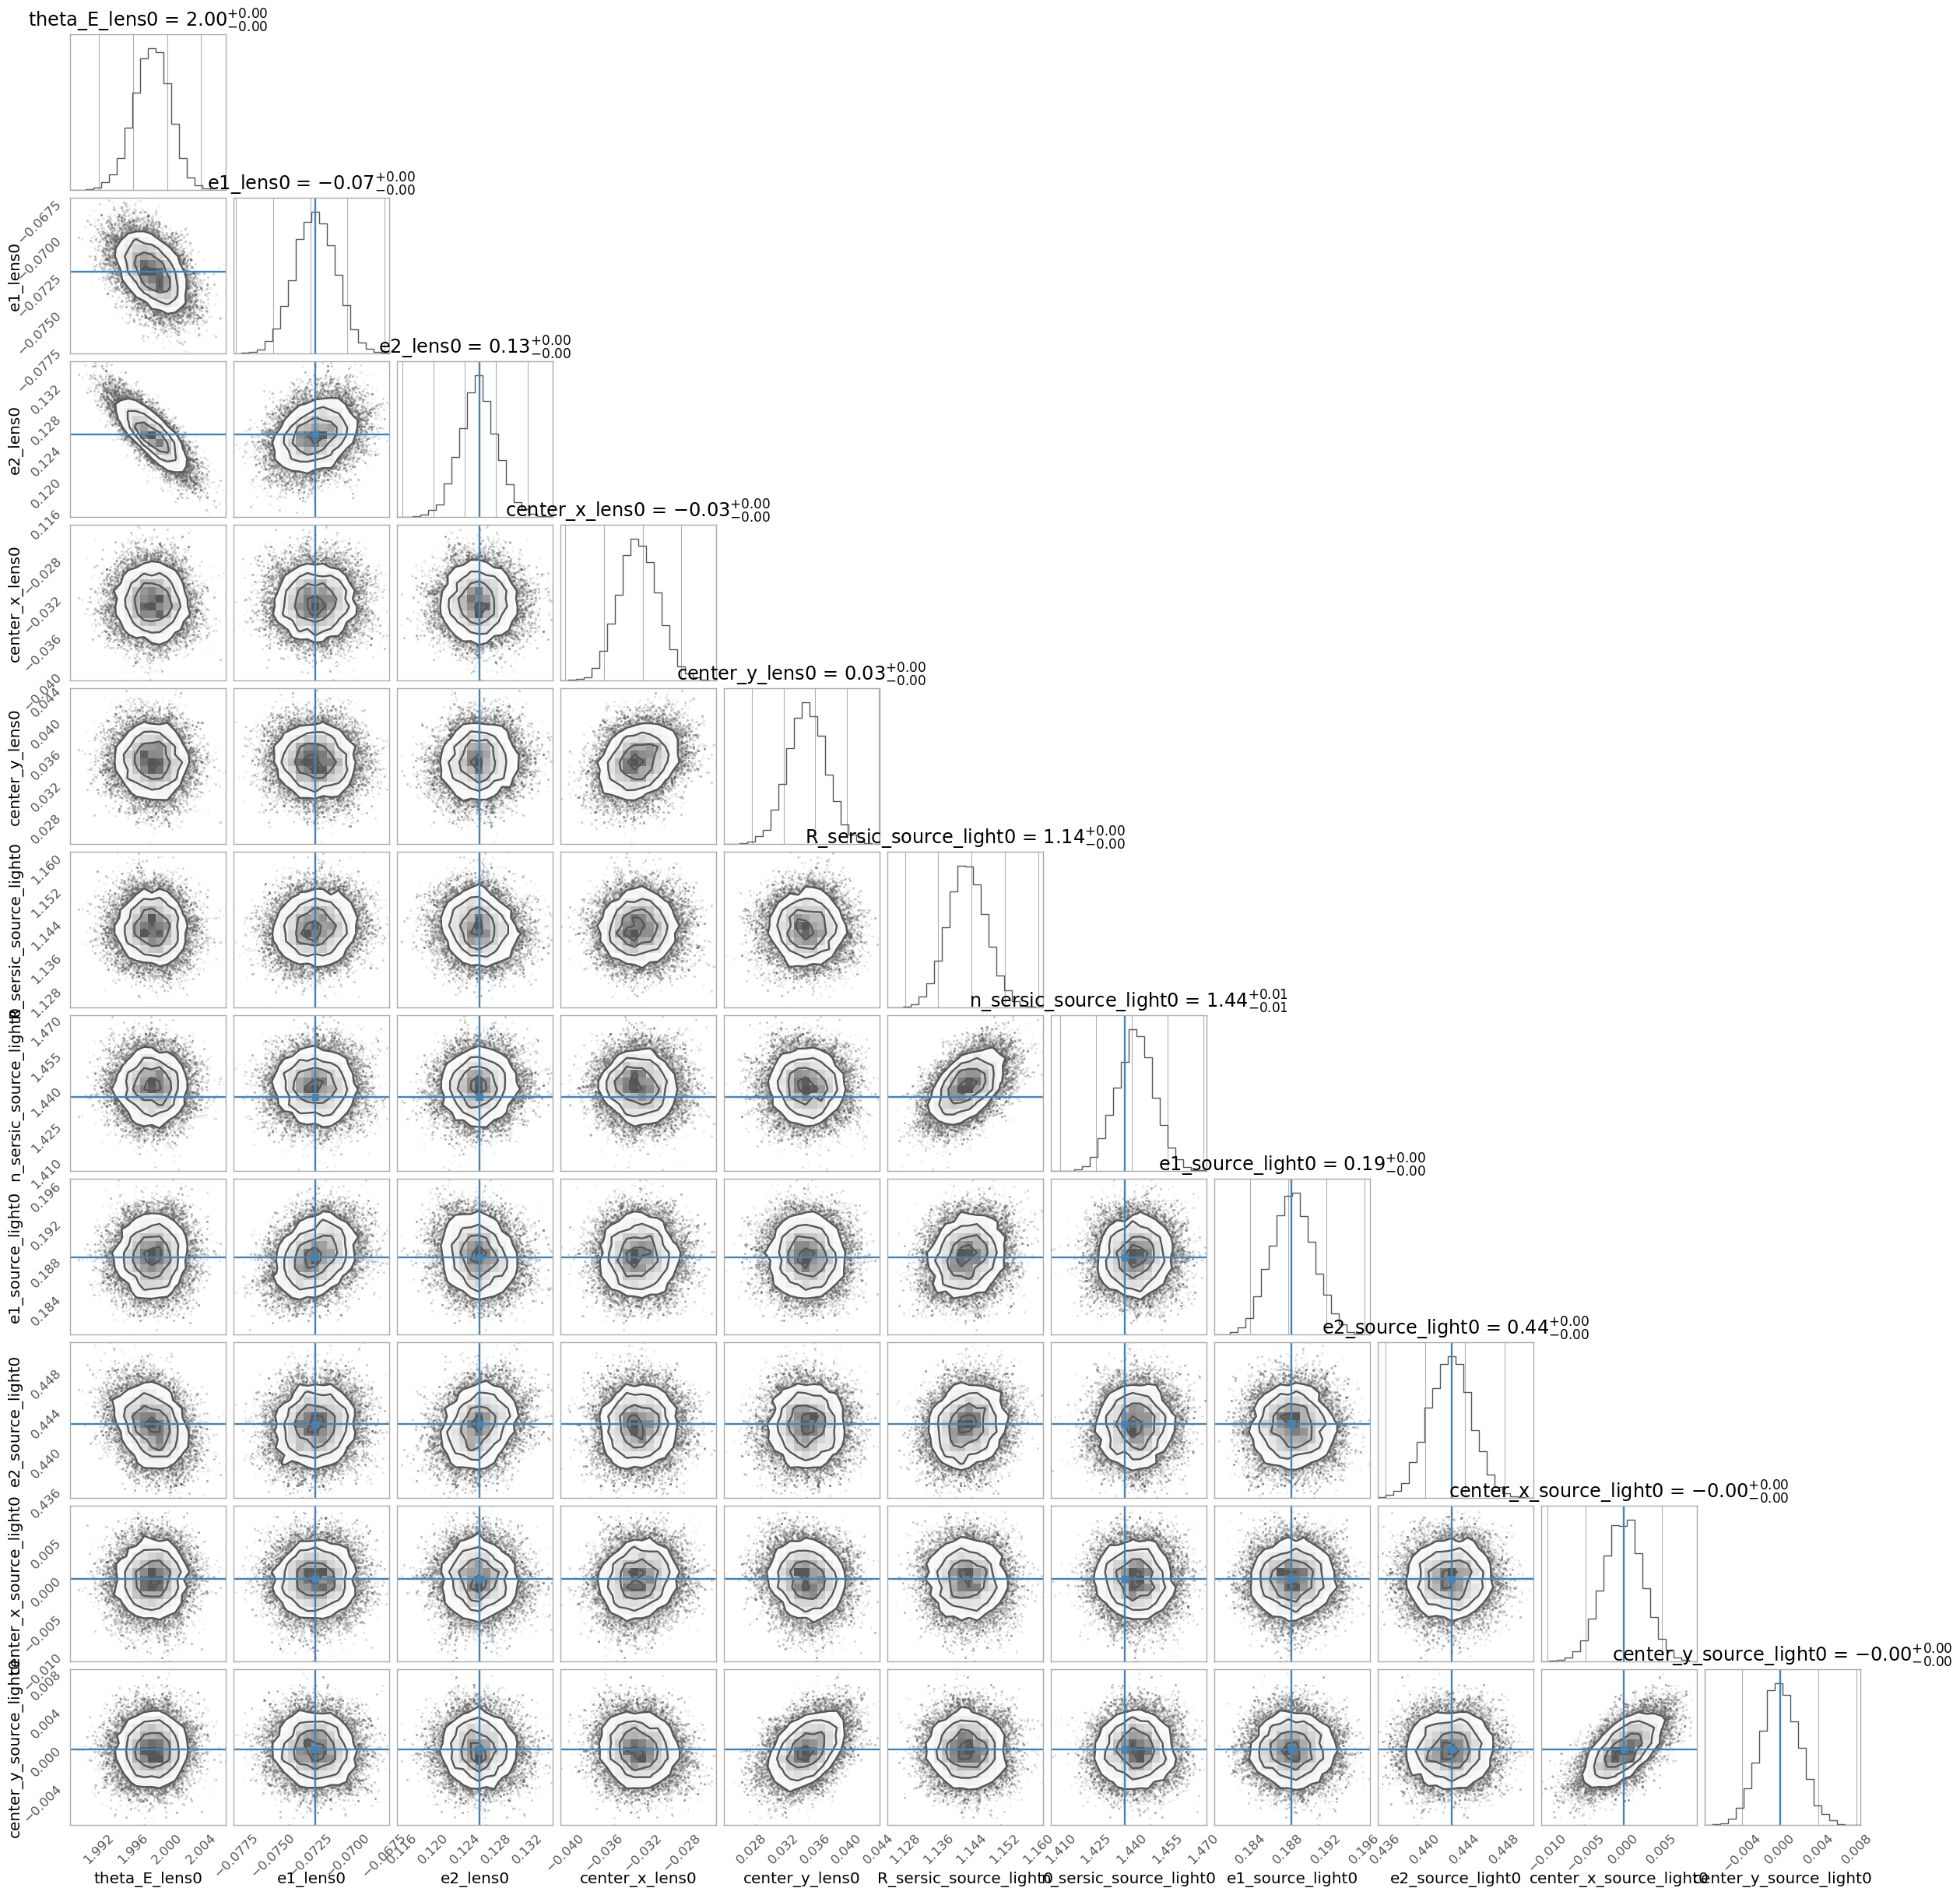

In [11]:
# Results of the MCMC chain

sampler_type, samples_mcmc, param_mcmc, dist_mcmc  = chain_list[1]

param_class = fitting_seq.param_class
param_truths = param_class.kwargs2args(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source)

# Plot MCMC chain
chain_plot.plot_chain_list(chain_list, 1)
if script:
    plt.savefig(f"{name}_chain.pdf", dpi=300, bbox_inches="tight")
else:
    plt.savefig(f"Modeling_results/{name}_chain.pdf", dpi=300, bbox_inches="tight")
    
print("number of non-linear parameters in the MCMC process: ", len(param_mcmc))
print("parameters in order: ", param_mcmc)
print("number of evaluations in the MCMC process: ", np.shape(samples_mcmc)[0])
n_sample = len(samples_mcmc)
print(n_sample)

# Corner plot
samples_mcmc_cut = samples_mcmc[int(n_sample*1/2.):]
if not np.shape(samples_mcmc)[0] == 0:
    n, num_param = np.shape(samples_mcmc_cut)
    plot = corner.corner(samples_mcmc_cut[:,:], labels=param_mcmc[:], show_titles=True, truths=param_truths)
    if script:
        plt.savefig(f"{name}_corner.pdf", dpi=300, bbox_inches="tight")
    else:
        plt.savefig(f"Modeling_results/{name}_corner.pdf", dpi=300, bbox_inches="tight")
        plt.show()
    plt.close() 

In [12]:
#Saving true and predicted parameter values
kwargs_truth = {'kwargs_lens': kwargs_lens, 'kwargs_source': kwargs_source}

df_true = pd.DataFrame()
dict_tmp1 = kwargs_truth['kwargs_lens'][0]
dict_tmp1 = {'lens_' + k: v for k, v in dict_tmp1.items()}
dict_tmp2 = kwargs_truth['kwargs_source'][0]
dict_tmp2 = {'source_' + k: v for k, v in dict_tmp2.items()}
dict_tmp = {**dict_tmp1, **dict_tmp2}
df_true = pd.concat([df_true, pd.DataFrame([dict_tmp])], ignore_index=True)
df_true

df_result = pd.DataFrame()
dict_tmp1 = kwargs_result['kwargs_lens'][0]
dict_tmp1 = {'lens_' + k: v for k, v in dict_tmp1.items()}
dict_tmp2 = kwargs_result['kwargs_source'][0]
dict_tmp2 = {'source_' + k: v for k, v in dict_tmp2.items()}
dict_tmp = {**dict_tmp1, **dict_tmp2}
df_result = pd.concat([df_result, pd.DataFrame([dict_tmp])], ignore_index=True)

if(script):
    df_result.to_csv(name + '_predicted.csv', index=False)
    df_true.to_csv(name + '_true.csv', index=False)
else: 
    df_result.to_csv('Modeling_results/' + name + '_predicted.csv', index=False)
    df_true.to_csv('Modeling_results/' + name + '_true.csv', index=False)